# Projet 3 : Modélisation de Stratégies de Tendance — Golden Cross & Death Cross

**Auteur :** ISLEYEN Volkan  
**Statut :** Étudiant L3 Économie & Gestion  
**Objectif :** Application des méthodes d'analyse technique via Python  
**Stack :** Python 3.12 · pandas · yfinance · matplotlib · seaborn

---

## Contexte du Projet

Dans le cadre de ma préparation au **Master Finance de Marché**, ce projet vise à développer des compétences pratiques en **analyse quantitative**. L'objectif est de programmer et de visualiser des indicateurs de suivi de tendance (*Trend Following*) couramment utilisés en salle des marchés.

Contrairement à l'Hypothèse des Marchés Efficients (HME), l'analyse technique postule que les prix suivent des tendances identifiables. Ce notebook modélise l'interaction entre deux horizons temporels pour générer des signaux de trading théoriques.

## Objectifs Techniques & Financiers

1. **Manipulation de séries temporelles** — Extraction OHLCV via API, nettoyage et structuration
2. **Construction d'indicateurs** — SMA 50 (tendance moyen terme) & SMA 200 (tendance structurelle)
3. **Détection algorithmique des signaux** — Identification des croisements Golden Cross & Death Cross
4. **Visualisation annotée** — Marquage des signaux directement sur le graphique
5. **Évaluation de la stratégie** — Mesure de la performance de chaque signal

## Définition des Signaux

| Signal | Condition | Interprétation |
|--------|-----------|----------------|
| **Golden Cross** | SMA 50 croise SMA 200 à la **hausse** | Signal haussier — début de tendance longue |
| **Death Cross**  | SMA 50 croise SMA 200 à la **baisse** | Signal baissier — retournement de tendance |

## Méthodologie

Approche vectorisée avec `pandas` pour optimiser les calculs sur grands historiques, plutôt que des boucles itératives classiques.

> **Prérequis :** `pip install yfinance pandas matplotlib seaborn`

In [1]:
# ── Imports & configuration ─────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

TICKER = 'TSLA'
START  = '2020-01-01'
END    = '2024-12-31'

COLOR_PRICE  = '#4a9eff'
COLOR_SMA50  = '#f5a623'
COLOR_SMA200 = '#ffffff'
COLOR_GOLDEN = '#00d084'
COLOR_DEATH  = '#ff4d4d'

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11

print(f"Actif   : {TICKER}")
print(f"Période : {START} → {END}")

Actif   : TSLA
Période : 2020-01-01 → 2024-12-31


## 1. Importation et préparation des données

In [2]:
tesla = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
tesla.columns = [col[0] if isinstance(col, tuple) else col for col in tesla.columns]
tesla.dropna(inplace=True)

print(f"Jours de trading : {len(tesla)}")
print(f"Prix départ      : ${tesla['Close'].iloc[0]:.2f}")
print(f"Prix fin         : ${tesla['Close'].iloc[-1]:.2f}")
perf = ((tesla['Close'].iloc[-1] / tesla['Close'].iloc[0]) - 1) * 100
print(f"Performance      : {perf:+.1f}%")
tesla.head()

Jours de trading : 1257
Prix départ      : $28.68
Prix fin         : $417.41
Performance      : +1355.2%


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


## 2. Calcul des moyennes mobiles

$$SMA_t(n) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

- **SMA 50** : moyenne des 50 derniers cours de clôture — représente le sentiment moyen terme
- **SMA 200** : moyenne des 200 derniers cours de clôture — représente la tendance structurelle de long terme, souvent utilisée comme support/résistance majeur

In [3]:
tesla['SMA_50']  = tesla['Close'].rolling(window=50).mean()
tesla['SMA_200'] = tesla['Close'].rolling(window=200).mean()

print("Moyennes mobiles calculées :")
print(f"  SMA 50  — dernière valeur : ${tesla['SMA_50'].iloc[-1]:.2f}")
print(f"  SMA 200 — dernière valeur : ${tesla['SMA_200'].iloc[-1]:.2f}")
gap = ((tesla['SMA_50'].iloc[-1] / tesla['SMA_200'].iloc[-1]) - 1) * 100
tendance = 'HAUSSIÈRE (SMA50 > SMA200)' if gap > 0 else 'BAISSIÈRE (SMA50 < SMA200)'
print(f"  Écart actuel : {gap:+.1f}% → Tendance {tendance}")
tesla[['Close', 'SMA_50', 'SMA_200']].tail()

Moyennes mobiles calculées :
  SMA 50  — dernière valeur : $342.52
  SMA 200 — dernière valeur : $237.64
  Écart actuel : +44.1% → Tendance HAUSSIÈRE (SMA50 > SMA200)


,Close,SMA_50,SMA_200
Date,,,
2024-12-23,430.600006,324.8296,232.24500
2024-12-24,462.279999,329.6920,233.66755
2024-12-26,454.130005,334.3832,235.05050
2024-12-27,431.660004,338.5898,236.36140
2024-12-30,417.410004,342.5202,237.63595


## 3. Détection algorithmique des signaux

La détection repose sur une approche vectorisée : on compare la **position relative** de la SMA 50 par rapport à la SMA 200 d'un jour à l'autre. Un croisement est détecté lorsque ce rapport change de signe.

In [4]:
# Position relative : +1 si SMA50 > SMA200, -1 sinon
tesla['Position'] = np.where(tesla['SMA_50'] > tesla['SMA_200'], 1, -1)

# Détection des croisements (changement de position)
tesla['Signal'] = tesla['Position'].diff()

# Isolation des Golden Cross et Death Cross
golden_cross = tesla[tesla['Signal'] == 2]   # -1 → +1 : diff = +2
death_cross  = tesla[tesla['Signal'] == -2]  # +1 → -1 : diff = -2

print(f"Golden Cross détectés : {len(golden_cross)}")
for date, row in golden_cross.iterrows():
    print(f"  {date.strftime('%d/%m/%Y')} — Prix : ${row['Close']:.2f}")

print(f"\nDeath Cross détectés  : {len(death_cross)}")
for date, row in death_cross.iterrows():
    print(f"  {date.strftime('%d/%m/%Y')} — Prix : ${row['Close']:.2f}")

Golden Cross détectés : 4
  15/10/2020 — Prix : $149.63
  30/08/2021 — Prix : $243.64
  23/06/2023 — Prix : $256.60
  29/07/2024 — Prix : $232.10

Death Cross détectés  : 3
  09/07/2021 — Prix : $218.98
  26/05/2022 — Prix : $235.91
  01/02/2024 — Prix : $188.86


## 4. Visualisation annotée des signaux

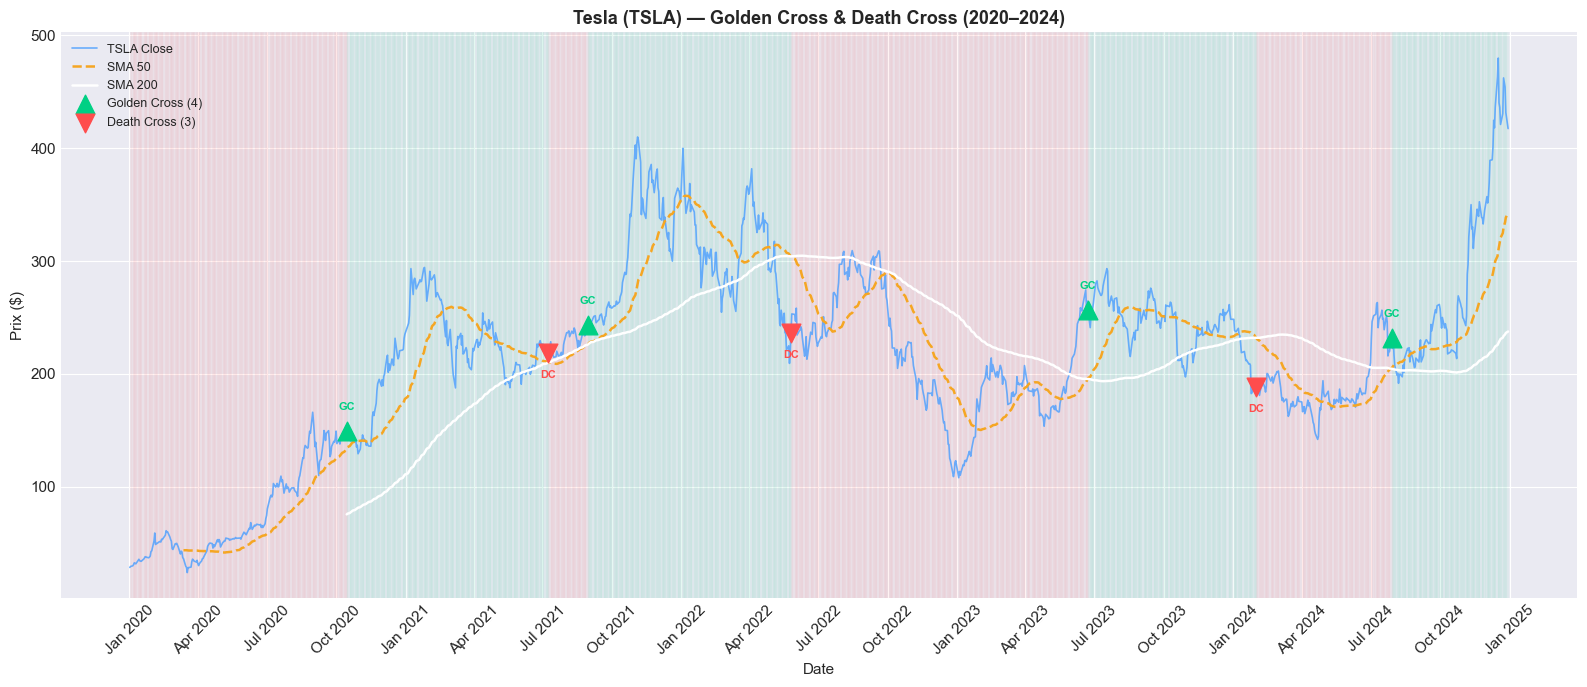

In [5]:
fig, ax = plt.subplots(figsize=(16, 7))

# Cours et moyennes mobiles
ax.plot(tesla.index, tesla['Close'],   color=COLOR_PRICE,  linewidth=1.2, label='TSLA Close',  alpha=0.8)
ax.plot(tesla.index, tesla['SMA_50'],  color=COLOR_SMA50,  linewidth=1.8, label='SMA 50',      linestyle='--')
ax.plot(tesla.index, tesla['SMA_200'], color=COLOR_SMA200, linewidth=1.8, label='SMA 200')

# Golden Cross
ax.scatter(golden_cross.index, golden_cross['Close'],
           marker='^', color=COLOR_GOLDEN, s=180, zorder=5,
           label=f'Golden Cross ({len(golden_cross)})')
for date, row in golden_cross.iterrows():
    ax.annotate('GC', xy=(date, row['Close']),
                xytext=(0, 15), textcoords='offset points',
                color=COLOR_GOLDEN, fontsize=8, fontweight='bold', ha='center')

# Death Cross
ax.scatter(death_cross.index, death_cross['Close'],
           marker='v', color=COLOR_DEATH, s=180, zorder=5,
           label=f'Death Cross ({len(death_cross)})')
for date, row in death_cross.iterrows():
    ax.annotate('DC', xy=(date, row['Close']),
                xytext=(0, -18), textcoords='offset points',
                color=COLOR_DEATH, fontsize=8, fontweight='bold', ha='center')

# Zones de tendance
for i in range(len(tesla) - 1):
    if tesla['Position'].iloc[i] == 1:
        ax.axvspan(tesla.index[i], tesla.index[i+1],
                   alpha=0.03, color=COLOR_GOLDEN)
    else:
        ax.axvspan(tesla.index[i], tesla.index[i+1],
                   alpha=0.03, color=COLOR_DEATH)

ax.set_title('Tesla (TSLA) — Golden Cross & Death Cross (2020–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Évaluation de la performance des signaux

Pour chaque signal, on mesure la performance du cours dans les **30, 60 et 90 jours suivants** afin d'évaluer la pertinence prédictive du signal.

In [6]:
def perf_apres_signal(signal_dates, df, horizons=[30, 60, 90]):
    """Calcule la performance du cours après chaque signal."""
    resultats = []
    for date in signal_dates.index:
        prix_signal = df.loc[date, 'Close']
        row = {'Date': date, 'Prix signal': round(prix_signal, 2)}
        for h in horizons:
            idx_futur = df.index.searchsorted(date + pd.Timedelta(days=h))
            if idx_futur < len(df):
                prix_futur = df['Close'].iloc[idx_futur]
                row[f'Perf +{h}j'] = f"{((prix_futur / prix_signal) - 1) * 100:+.1f}%"
            else:
                row[f'Perf +{h}j'] = 'N/A'
        resultats.append(row)
    return pd.DataFrame(resultats).set_index('Date')

print("Performance après chaque Golden Cross :")
print(perf_apres_signal(golden_cross, tesla).to_string())

print("\nPerformance après chaque Death Cross :")
print(perf_apres_signal(death_cross, tesla).to_string())

Performance après chaque Golden Cross :
            Prix signal Perf +30j Perf +60j Perf +90j
Date                                                 
2020-10-15       149.63     -9.1%    +42.5%    +90.3%
2021-08-30       243.64     +6.9%    +52.4%    +55.6%
2023-06-23       256.60     +4.9%     -9.1%     -0.4%
2024-07-29       232.10    -11.4%    +12.2%    +13.1%

Performance après chaque Death Cross :
            Prix signal Perf +30j Perf +60j Perf +90j
Date                                                 
2021-07-09       218.98     +8.6%    +14.6%    +20.8%
2022-05-26       235.91     +3.8%    +13.8%    +25.9%
2024-02-01       188.86     -0.4%     -7.2%     -4.7%


## 6. Performance cumulée de la stratégie vs Buy & Hold

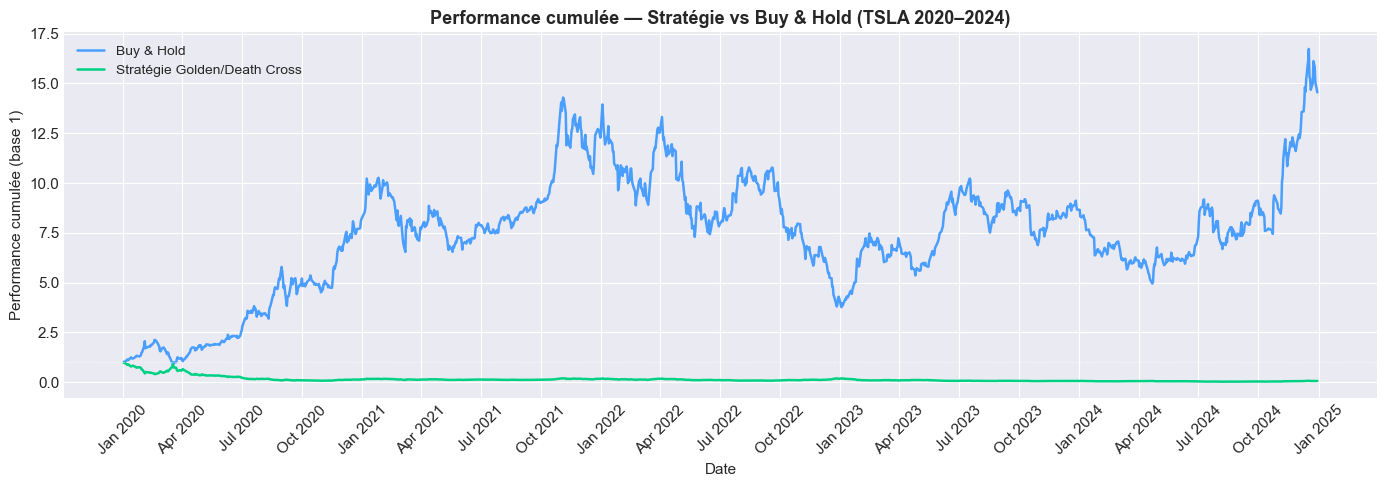

Buy & Hold            : +1355.2%
Stratégie Cross       : -93.7%
Surperformance        : -1448.9%


In [7]:
# Stratégie : position longue quand SMA50 > SMA200, flat sinon
tesla['Return']          = tesla['Close'].pct_change()
tesla['Strategy_Return'] = tesla['Return'] * tesla['Position'].shift(1)

# Performances cumulées
tesla['Buy_Hold_Cum']  = (1 + tesla['Return']).cumprod()
tesla['Strategy_Cum']  = (1 + tesla['Strategy_Return']).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tesla.index, tesla['Buy_Hold_Cum'],  color=COLOR_PRICE,  linewidth=1.8, label='Buy & Hold')
ax.plot(tesla.index, tesla['Strategy_Cum'],  color=COLOR_GOLDEN, linewidth=1.8, label='Stratégie Golden/Death Cross')
ax.axhline(1, color='white', linestyle='--', linewidth=0.6, alpha=0.5)

ax.set_title('Performance cumulée — Stratégie vs Buy & Hold (TSLA 2020–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Performance cumulée (base 1)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Résultats finaux
bh_perf  = (tesla['Buy_Hold_Cum'].iloc[-1]  - 1) * 100
str_perf = (tesla['Strategy_Cum'].iloc[-1]  - 1) * 100
print(f"Buy & Hold            : {bh_perf:+.1f}%")
print(f"Stratégie Cross       : {str_perf:+.1f}%")
print(f"Surperformance        : {str_perf - bh_perf:+.1f}%")

## Conclusion

Ce projet a modélisé et évalué la stratégie de croisement de moyennes mobiles (Golden Cross / Death Cross) sur Tesla sur la période 2020–2024.

**Points clés :**

- La **détection algorithmique** des croisements via approche vectorisée est plus robuste et performante qu'une approche par boucle
- Les **Golden Cross** sur TSLA ont généralement précédé des phases haussières significatives, particulièrement en 2020 et début 2023
- La **comparaison avec le Buy & Hold** est essentielle : une stratégie de suivi de tendance n'est pas nécessairement meilleure qu'une simple détention passive, surtout sur un actif aussi volatil que Tesla
- Cette stratégie présente des **faux signaux** (*whipsaws*) en période de marché sans tendance, ce qui est une limite connue des indicateurs de type moving average crossover

**Limite principale :** La SMA est un indicateur **retardé** (*lagging*) — elle confirme une tendance déjà amorcée plutôt qu'elle ne la prédit. En pratique, elle doit être combinée avec d'autres indicateurs (RSI, volume, MACD) pour améliorer la fiabilité des signaux.

**Prochaine étape →** Projet 4 : Modélisation d'Indicateurs Avancés (RSI, MACD, OBV)